1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# Load cleaned dataset
df = pd.read_csv("online_retail_cleaned.csv")

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Shape:", df.shape)

df.head()

Shape: (392692, 16)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Month_Name,Year_Month,Day_Name,Day,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,December,2010-12,Wednesday,1,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,2010-12,Wednesday,1,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,December,2010-12,Wednesday,1,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,2010-12,Wednesday,1,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,2010-12,Wednesday,1,8


2. Create Transaction Month

In [2]:
df["Transaction_Month"] = (df["InvoiceDate"].dt.to_period("M"))

df[["CustomerID", "InvoiceDate", "Transaction_Month"]].head()

,CustomerID,InvoiceDate,Transaction_Month
0,17850,2010-12-01 08:26:00,2010-12
1,17850,2010-12-01 08:26:00,2010-12
2,17850,2010-12-01 08:26:00,2010-12
3,17850,2010-12-01 08:26:00,2010-12
4,17850,2010-12-01 08:26:00,2010-12


3. Find Each Customer's First Purchase Month

In [3]:
customer_cohort = (df.groupby("CustomerID")["Transaction_Month"].min().reset_index())

customer_cohort.columns = ["CustomerID","Cohort_Month"]

customer_cohort.head()

,CustomerID,Cohort_Month
0,12346,2011-01
1,12347,2010-12
2,12348,2010-12
3,12349,2011-11
4,12350,2011-02


4. Merge Cohort Month Back into Main Dataset

In [4]:
df = df.merge(customer_cohort,on="CustomerID",how="left")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Month_Name,Year_Month,Day_Name,Day,Hour,Transaction_Month,Cohort_Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,December,2010-12,Wednesday,1,8,2010-12,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,2010-12,Wednesday,1,8,2010-12,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,December,2010-12,Wednesday,1,8,2010-12,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,2010-12,Wednesday,1,8,2010-12,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,2010-12,Wednesday,1,8,2010-12,2010-12


5. Calculate Cohort Index

In [5]:
transaction_year = (df["Transaction_Month"].dt.year)

transaction_month = (df["Transaction_Month"].dt.month)

cohort_year = (df["Cohort_Month"].dt.year)

cohort_month = (df["Cohort_Month"].dt.month)

In [6]:
df["Cohort_Index"] = ((transaction_year - cohort_year) * 12 + (transaction_month - cohort_month))

df[[ "CustomerID",
      "Transaction_Month",
       "Cohort_Month",
       "Cohort_Index"]].head(10)

,CustomerID,Transaction_Month,Cohort_Month,Cohort_Index
0,17850,2010-12,2010-12,0
1,17850,2010-12,2010-12,0
2,17850,2010-12,2010-12,0
3,17850,2010-12,2010-12,0
4,17850,2010-12,2010-12,0
5,17850,2010-12,2010-12,0
6,17850,2010-12,2010-12,0
7,17850,2010-12,2010-12,0
8,17850,2010-12,2010-12,0
9,13047,2010-12,2010-12,0


6. Create Cohort Table

In [7]:
cohort_data = (df.groupby(["Cohort_Month","Cohort_Index"])["CustomerID"].nunique().reset_index())

cohort_data.head()

,Cohort_Month,Cohort_Index,CustomerID
0,2010-12,0,885
1,2010-12,1,324
2,2010-12,2,286
3,2010-12,3,340
4,2010-12,4,321


7. Create the Cohort Matrix

In [8]:
cohort_matrix = (cohort_data.pivot(index="Cohort_Month",columns="Cohort_Index",values="CustomerID"))

cohort_matrix

Cohort_Index,0,1,2,3,4,5,6,7,8,9,10,11,12
Cohort_Month,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


8. Calculate Retention Rate

In [9]:
cohort_size = cohort_matrix.iloc[:, 0]

retention_matrix = (cohort_matrix.divide(cohort_size,axis=0) * 100)

retention_matrix.round(2)

Cohort_Index,0,1,2,3,4,5,6,7,8,9,10,11,12
Cohort_Month,,,,,,,,,,,,,
2010-12,100.0,36.61,32.32,38.42,36.27,39.77,36.27,34.92,35.37,39.55,37.40,50.28,26.55
2011-01,100.0,22.06,26.62,23.02,32.13,28.78,24.70,24.22,29.98,32.61,36.45,11.75,NaN
2011-02,100.0,18.68,18.68,28.42,27.11,24.74,25.26,27.89,24.74,30.53,6.84,NaN,NaN
2011-03,100.0,15.04,25.22,19.91,22.35,16.81,26.77,23.01,27.88,8.63,NaN,NaN,NaN
2011-04,100.0,21.33,20.33,21.00,19.67,22.67,21.67,26.00,7.33,NaN,NaN,NaN,NaN
2011-05,100.0,19.01,17.25,17.25,20.77,23.24,26.41,9.51,NaN,NaN,NaN,NaN,NaN
2011-06,100.0,17.36,15.70,26.45,23.14,33.47,9.50,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,100.0,18.09,20.74,22.34,27.13,11.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,100.0,20.71,24.85,24.26,12.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


9. Create the Cohort Retention Heatmap

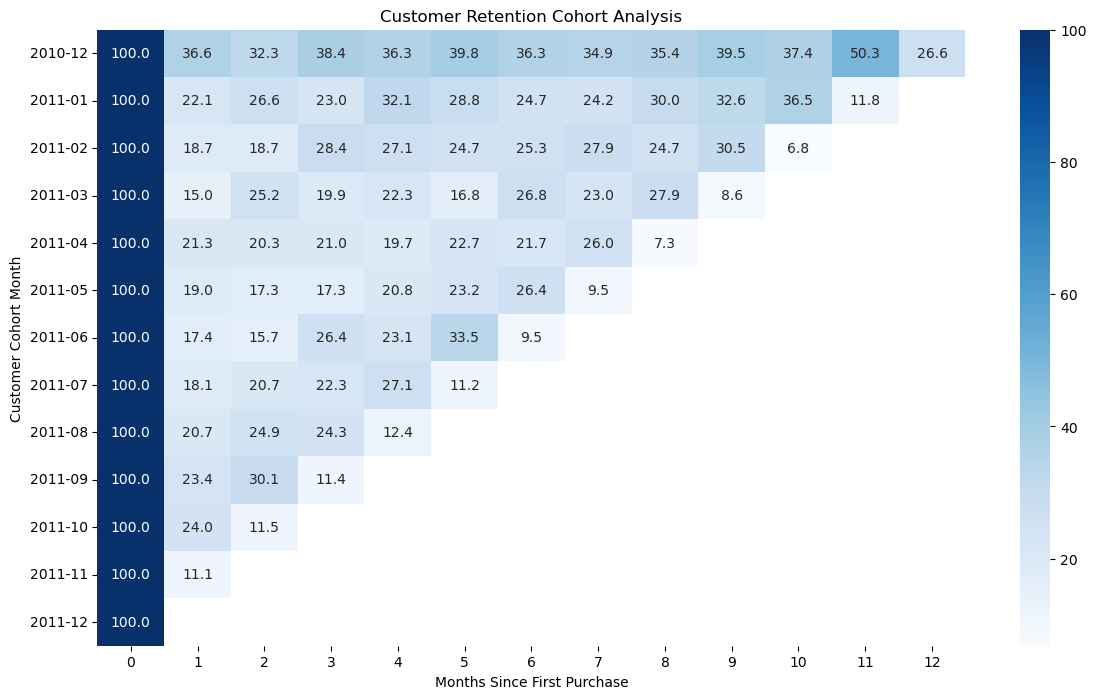

In [10]:
plt.figure(figsize=(14, 8))

sns.heatmap(retention_matrix,annot=True,fmt=".1f",cmap="Blues")

plt.title("Customer Retention Cohort Analysis")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Customer Cohort Month")

plt.show()

10. Improve the Cohort Labels

In [11]:
retention_matrix.index = (retention_matrix.index.astype(str))

retention_matrix.index.name = "Cohort Month"

retention_matrix

Cohort_Index,0,1,2,3,4,5,6,7,8,9,10,11,12
Cohort Month,,,,,,,,,,,,,
2010-12,100.0,36.610169,32.316384,38.418079,36.271186,39.774011,36.271186,34.915254,35.367232,39.548023,37.401130,50.282486,26.553672
2011-01,100.0,22.062350,26.618705,23.021583,32.134293,28.776978,24.700240,24.220624,29.976019,32.613909,36.450839,11.750600,NaN
2011-02,100.0,18.684211,18.684211,28.421053,27.105263,24.736842,25.263158,27.894737,24.736842,30.526316,6.842105,NaN,NaN
2011-03,100.0,15.044248,25.221239,19.911504,22.345133,16.814159,26.769912,23.008850,27.876106,8.628319,NaN,NaN,NaN
2011-04,100.0,21.333333,20.333333,21.000000,19.666667,22.666667,21.666667,26.000000,7.333333,NaN,NaN,NaN,NaN
2011-05,100.0,19.014085,17.253521,17.253521,20.774648,23.239437,26.408451,9.507042,NaN,NaN,NaN,NaN,NaN
2011-06,100.0,17.355372,15.702479,26.446281,23.140496,33.471074,9.504132,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,100.0,18.085106,20.744681,22.340426,27.127660,11.170213,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,100.0,20.710059,24.852071,24.260355,12.426036,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


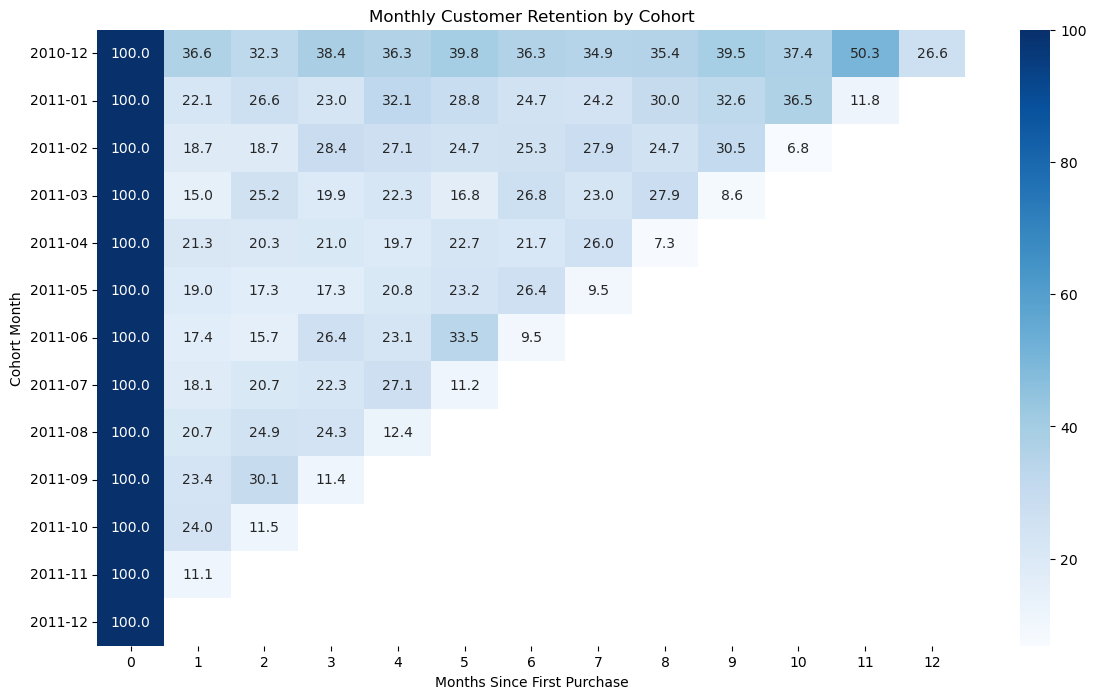

In [12]:
plt.figure(figsize=(14, 8))

sns.heatmap(retention_matrix,annot=True,fmt=".1f",cmap="Blues")

plt.title("Monthly Customer Retention by Cohort")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

11. Analyze Average Retention by Month

In [13]:
average_retention = (retention_matrix.mean().reset_index())

average_retention.columns = ["Months_After_First_Purchase","Average_Retention_Rate"]

average_retention

,Months_After_First_Purchase,Average_Retention_Rate
0,0,100.000000
1,1,20.623180
2,2,22.116316
3,3,23.244404
4,4,24.554598
5,5,25.081173
6,6,24.369106
7,7,24.257751
8,8,25.057906
9,9,27.829141


12. Visualize Average Retention

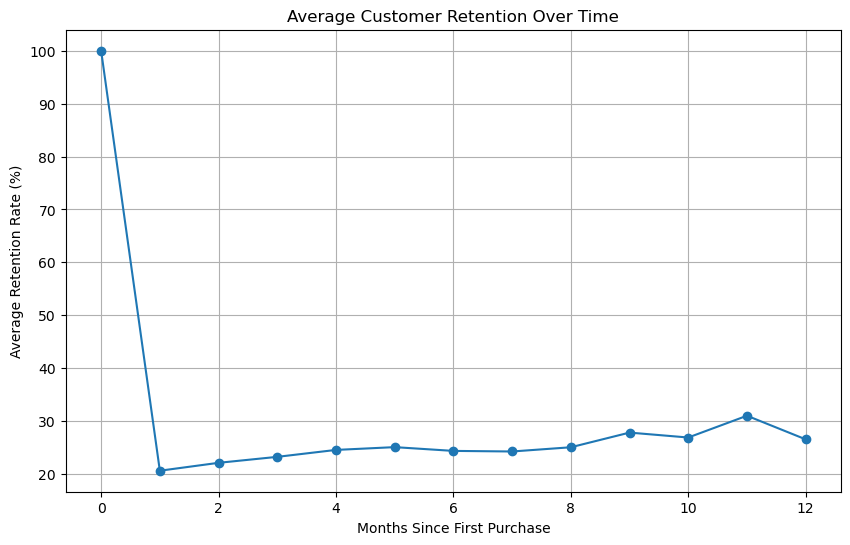

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(average_retention["Months_After_First_Purchase"], 
         average_retention["Average_Retention_Rate"],marker="o")

plt.title("Average Customer Retention Over Time")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Average Retention Rate (%)")

plt.grid()

plt.show()

13. Find the Best and Worst Cohorts

In [16]:
# compare Month 1 retention.

month_1_retention = (retention_matrix[1].sort_values(ascending=False))

month_1_retention

Cohort Month
2010-12    36.610169
2011-10    24.022346
2011-09    23.411371
2011-01    22.062350
2011-04    21.333333
2011-08    20.710059
2011-05    19.014085
2011-02    18.684211
2011-07    18.085106
2011-06    17.355372
2011-03    15.044248
2011-11    11.145511
2011-12          NaN
Name: 1, dtype: float64

In [17]:
# Best cohort

best_cohort = (month_1_retention.idxmax())

best_retention = (month_1_retention.max())

print("Best Cohort:", best_cohort)
print( f"Month 1 Retention: " f"{best_retention:.2f}%")

Best Cohort: 2010-12
Month 1 Retention: 36.61%


In [18]:
# Worst cohort

worst_cohort = (month_1_retention.idxmin())

worst_retention = ( month_1_retention.min())

print("Worst Cohort:", worst_cohort)
print( f"Month 1 Retention: " f"{worst_retention:.2f}%")

Worst Cohort: 2011-11
Month 1 Retention: 11.15%


14. Cohort Analysis Summary

In [19]:
cohort_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Number of Cohorts",
        "Best Month 1 Cohort",
        "Best Month 1 Retention",
        "Worst Month 1 Cohort",
        "Worst Month 1 Retention",
        "Average Month 1 Retention"
    ],
    
    "Value": [
        df["CustomerID"].nunique(),
        retention_matrix.shape[0],
        str(best_cohort),
        f"{best_retention:.2f}%",
        str(worst_cohort),
        f"{worst_retention:.2f}%",
        f"{retention_matrix[1].mean():.2f}%"
    ]
})

cohort_summary

,Metric,Value
0,Total Customers,4338
1,Number of Cohorts,13
2,Best Month 1 Cohort,2010-12
3,Best Month 1 Retention,36.61%
4,Worst Month 1 Cohort,2011-11
5,Worst Month 1 Retention,11.15%
6,Average Month 1 Retention,20.62%
